<a href="https://colab.research.google.com/github/Krishna-97/python-assignment-part4-bitsom_ba_2511994/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1 — Data Exploration with Pandas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
df = pd.read_csv("students.csv")
df

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0
5,Frank,60,65,72,58,70,78,2.5,1
6,Grace,55,48,44,52,62,60,1.5,0
7,Henry,82,79,85,77,90,88,4.0,1
8,Iris,70,74,68,65,78,80,3.5,1
9,Jack,30,35,40,28,45,50,0.5,0


**1. Displaying First 5 rows of df**

In [2]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
       name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


**2. Displaying the Shape and Data Types of df**

In [3]:
print(f"\nShape: {df.shape}")
print("\nData Types:\n", df.dtypes)


Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


**3. Summary Statistics of df**

In [4]:
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
             math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%              

**4. Displaying Pass/Fail Count of df**

In [5]:
print("\nPass/Fail Counts:\n", df['passed'].value_counts())


Pass/Fail Counts:
 passed
1    9
0    6
Name: count, dtype: int64


**5. Displaying Average score per subject by Pass/Fail of df**

In [6]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()
print("\nAvg Score (Passing Students):\n", pass_avg)
print("\nAvg Score (Failing Students):\n", fail_avg)


Avg Score (Passing Students):
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Avg Score (Failing Students):
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


**6.Displaying the student with highest overall average of df**

In [7]:
df['avg_score'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_score'].idxmax()]
print(f"\nTop Student: {top_student['name']} with average {top_student['avg_score']:.2f}")


Top Student: Diana with average 94.00


# **Task 2 — Data Visualization with Matplotlib**

**1.Displaying and Saving Bar Chart - Avg per Subject**

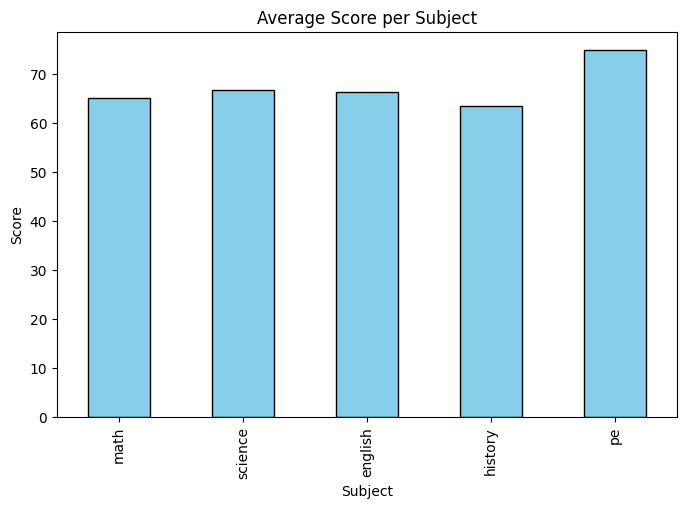

In [8]:
plt.figure(figsize=(8, 5))
df[subject_cols].mean().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Score per Subject")
plt.ylabel("Score")
plt.xlabel("Subject")
plt.savefig("plot1_bar.png")
plt.show()

**2. Displaying and Saving Histogram - Math Scores**

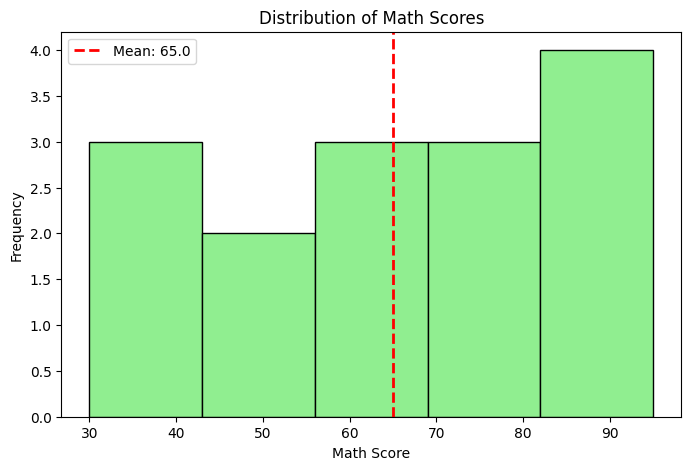

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['math'].mean():.1f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

**3. Displaying and Saving Scatter Plot - Study Hours vs Avg Score**

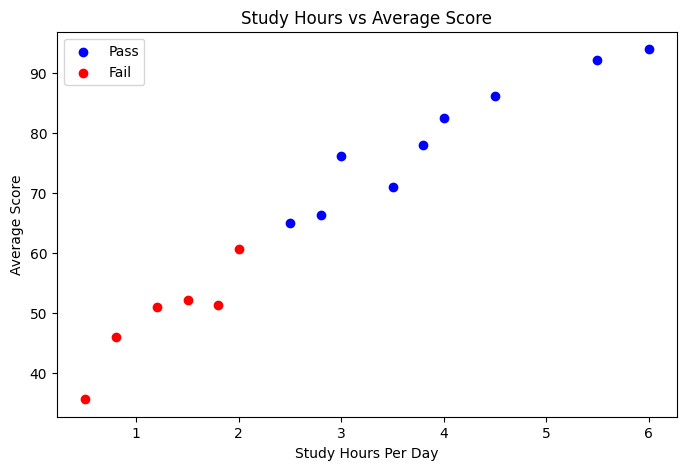

In [10]:
plt.figure(figsize=(8, 5))
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], color='blue', label='Pass')
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

**4. Displaying and Saving Box Plot - Attendance**

/tmp/ipykernel_7350/1682743519.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


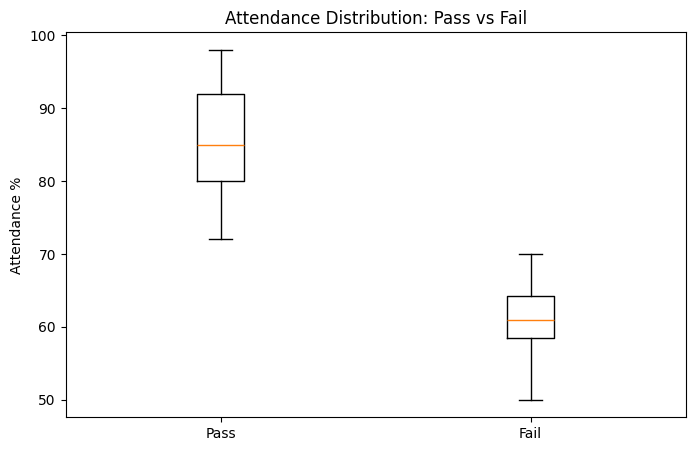

In [11]:
plt.figure(figsize=(8, 5))
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

**5. Displaying and Saving Line Plot - Math vs Science**

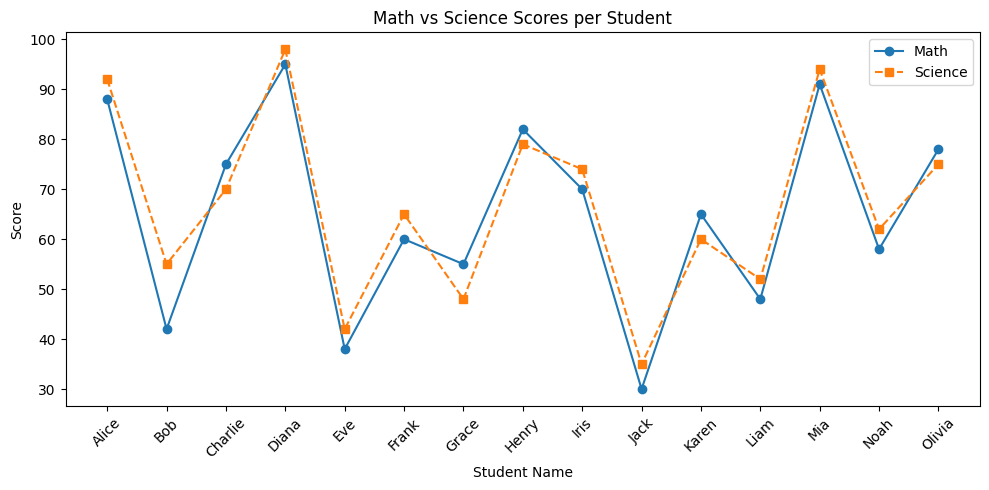

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', linestyle='-')
plt.plot(df['name'], df['science'], marker='s', label='Science', linestyle='--')
plt.xticks(rotation=45)
plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

# **Task 3 — Data Visualization with Seaborn**


**1. Displaying and Saving Seaborn Subplots for Math and Science**

/tmp/ipykernel_7350/3523323971.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
/tmp/ipykernel_7350/3523323971.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='muted')


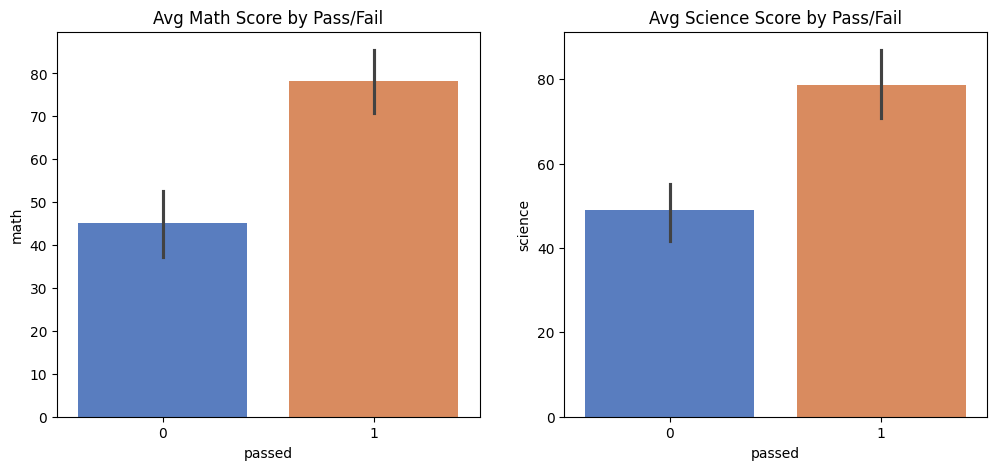

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
ax1.set_title("Avg Math Score by Pass/Fail")
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='muted')
ax2.set_title("Avg Science Score by Pass/Fail")
plt.savefig("seaborn_bars.png")
plt.show()

**2. Seaborn Regression Plot**

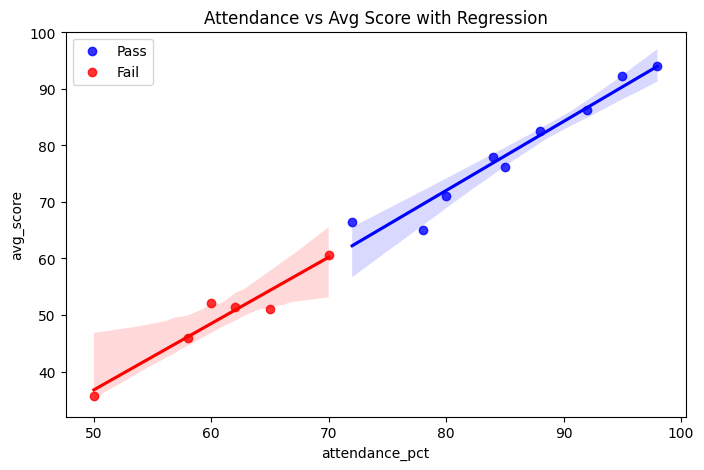

In [14]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red')
plt.title("Attendance vs Avg Score with Regression")
plt.legend()
plt.savefig("seaborn_reg.png")
plt.show()


**Experience Comparison:**

*Matplotlib offers granular control but requires more lines of code to handle grouping and styling (like the manual scatter loops).
Seaborn is much more efficient for statistical relationships; functions like regplot() and the automatic aggregation in barplot()
save significant time, though it can sometimes feel less intuitive when you need very specific non-standard layout tweaks.*


# **Task 4 — Machine Learning with scikit-learn**

**Step 1 — Prepare Data:**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Step 2 — Train a Model:**

In [16]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_acc:.2f}")

Training Accuracy: 1.00


**Step 3 — Evaluate the Model:**

In [17]:
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.2f}\n")

print("Test Set Predictions:")
for i, idx in enumerate(X_test.index):
    name = df.loc[idx, 'name']
    actual = y_test.iloc[i]
    pred = y_pred[i]
    status = "✅" if actual == pred else "❌"
    print(f"{name}: Actual={actual}, Predicted={pred} {status}")

Test Accuracy: 1.00

Test Set Predictions:
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅


**Step 4 — Feature Importance:**


Feature Importance (Sorted):
                Feature      Coef
2              english  0.812513
5       attendance_pct  0.521876
6  study_hours_per_day  0.484433
4                   pe  0.474974
0                 math  0.437944
1              science  0.323010
3              history  0.262929


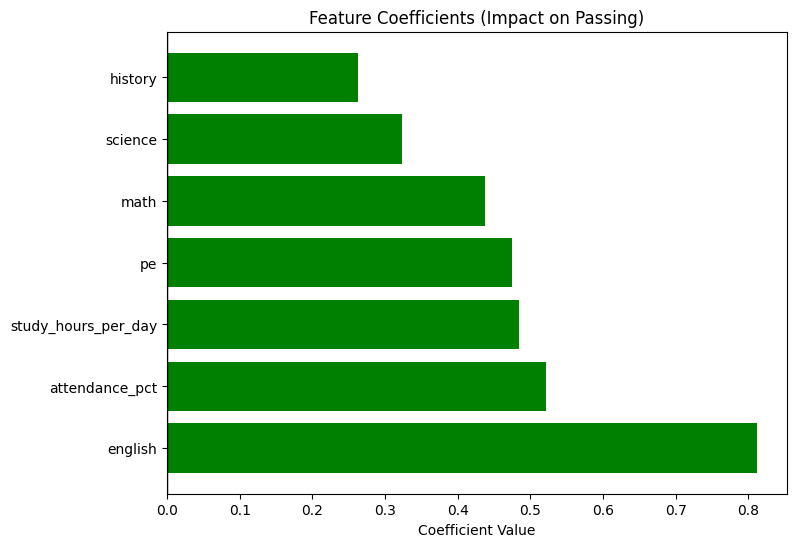

In [18]:
coeffs = model.coef_[0]
feat_importance = pd.DataFrame({'Feature': features, 'Coef': coeffs})
feat_importance['AbsCoef'] = feat_importance['Coef'].abs()
feat_importance = feat_importance.sort_values(by='AbsCoef', ascending=False)

print("\nFeature Importance (Sorted):\n", feat_importance[['Feature', 'Coef']])

plt.figure(figsize=(8, 6))
colors = ['green' if c > 0 else 'red' for c in feat_importance['Coef']]
plt.barh(feat_importance['Feature'], feat_importance['Coef'], color=colors)
plt.title("Feature Coefficients (Impact on Passing)")
plt.xlabel("Coefficient Value")
plt.axvline(0, color='black', lw=1)
plt.show()

**Step 5 — Predict for a New Student**

In [19]:
new_student = [[75, 72, 88, 75, 80, 85, 3.7]]  # order must match feature columns
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)[0]
prob = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"
print(f"\nNew Student Prediction: {result}")
print(f"Probabilities: Fail={prob[0]:.2f}, Pass={prob[1]:.2f}")


New Student Prediction: Pass
Probabilities: Fail=0.02, Pass=0.98


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
